## Import Libraries and Data

In [201]:
import pandas as pd
import numpy as np

In [202]:
# This code was given by Simon Clarke!!
# sep=',|\t' is another way to split the clusted data that were not splited by ',' as they should be (csv = comma-seperated values)
# on_bad_lines='warn' is just to signal a warning that there are bad lines in the data (it will just 'warn' us, not 'skip' like what we did)

raw_df = pd.read_csv('Data/Melbourne01.csv',names=["Year", "Month", "Day", "Hour", "Minute",
                                          "Air Temp (degrees C)",
                                          "Apparent Temp (degrees C)", "Dew Pt Temp (degrees C)", "Humidity (%)",
                                          "Wind Direction", "Wind Speed (km/h)", "Wind Gust  (km/h)",
                                          "MSLP (hPa)",
                                          "Rainfall since 9 am (mm)", "Dummy1", "Dummy2"],
                sep=',|\t', on_bad_lines='warn')

/var/folders/7c/mz5k512d14v8zwhmbghmxxl80000gn/T/ipykernel_1902/1274739746.py:5: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_df = pd.read_csv('Data/Melbourne01.csv',names=["Year", "Month", "Day", "Hour", "Minute",


In [203]:
raw_df

# Just to get an idea what the raw data looks like

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
2,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
4,2011.0,1,1,0,24,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113280,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
1113281,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
1113282,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
1113283,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


In [204]:
print(raw_df.isna().sum())

# 133 rows of missing value in 'Year' column is due to the shfted thing...
# For Dummy1, Dummy2 we have no idea what they are....

Year                             133
Month                              0
Day                                0
Hour                               0
Minute                             0
Air Temp (degrees C)               0
Apparent Temp (degrees C)          0
Dew Pt Temp (degrees C)            0
Humidity (%)                       0
Wind Direction                     0
Wind Speed (km/h)                  0
Wind Gust  (km/h)                  0
MSLP (hPa)                         0
Rainfall since 9 am (mm)           0
Dummy1                       1113152
Dummy2                       1113152
dtype: int64


## Data Formating

In [205]:
df = raw_df.drop_duplicates()    # drop duplicated rows
df = df.reset_index(drop=True)   # resetting the index after dropping some rows
df.tail()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
576083,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN
576087,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,NW,28.0,35.0,1014.1,0.0,NaN,NaN


In [206]:
shifted_rows_index = df.index[df['Year'].isna()].tolist()  # list out all the shifted rows (missing value in 'Year' column)
df.loc[shifted_rows_index]

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
121011,NaN,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,NaN,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,NaN,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,NaN,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,NaN,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,NaN,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,NaN,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,NaN,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,NaN,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


From the table above, we can see that ther are no values in the Year column because all the data are shifted one column to the right.

### Dealing with shifted rows

In [207]:
df_fixing = df.loc[shifted_rows_index]  # Create another df for those shifted rows
df_fixing

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
121011,NaN,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,NaN,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,NaN,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,NaN,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,NaN,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,NaN,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,NaN,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,NaN,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,NaN,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


In [208]:
df_fixing.drop(columns=['Year'], inplace=True)  # Droping Year column since it has no data in it

In [209]:
col_names=['Year', "Month", "Day", "Hour", "Minute", "Air Temp (degrees C)", "Apparent Temp (degrees C)", 
           "Dew Pt Temp (degrees C)", "Humidity (%)", "Wind Direction", "Wind Speed (km/h)", "Wind Gust  (km/h)",
            "MSLP (hPa)", "Rainfall since 9 am (mm)", "Dummy1"]

df_fixing.columns = col_names # Rename all the column names after dropping Year column
df_fixing

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1
121011,2013,9,6,17,0.0,14.9,11.4,5.6,53,N,20.0,22.0,1024.3,0.0,53.0
121012,2013,9,6,17,30.0,14.7,11.8,6.4,57,N,13.0,17.0,1024.2,0.0,57.0
121013,2013,9,6,18,0.0,14.4,11.6,7.0,61,N,13.0,17.0,1024.3,0.0,61.0
121014,2013,9,6,18,30.0,14.1,11.1,7.6,65,N,17.0,20.0,1024.1,0.0,65.0
121015,2013,9,6,19,0.0,14.1,10.6,7.1,62,N,15.0,19.0,1024.5,0.0,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121139,2013,9,9,9,0.0,16.3,6.5,2.0,38,N,56.0,70.0,1012,0.2,38.0
121140,2013,9,9,9,30.0,17.1,6.2,1.3,34,N,56.0,72.0,1011.4,0.0,34.0
121141,2013,9,9,10,0.0,18.0,7.6,-0.2,29,N,56.0,74.0,1010.8,0.0,29.0
121142,2013,9,9,10,30.0,18.6,7.7,-1.0,26,N,54.0,69.0,1010.2,0.0,26.0


We can see that all the data are shifted back and have correct column names. But you can see that 'Dummy2' column is gone. But we don't really care (right?) because we don't know what it is for.

### Merge them back together

In [210]:
df.drop(df.index[shifted_rows_index], inplace=True) # Drop all the shifted rows from 'df' to get only non-shifted rows
df

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,14,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
2,2011.0,1,1,0,24,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,34,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0.0,NaN,NaN
4,2011.0,1,1,0,44,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


In [211]:
all_df = pd.concat([df, df_fixing])  # Combining the non-shifted df with the shifted df (which has already been fixed)
all_df = all_df.sort_index()         # Sort all those rows back into place
all_df

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
0,2011.0,1,1,0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0.0,NaN,NaN
1,2011.0,1,1,0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0.0,NaN,NaN
2,2011.0,1,1,0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0.0,NaN,NaN
3,2011.0,1,1,0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0.0,NaN,NaN
4,2011.0,1,1,0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30.0,33.4,32.5,14.9,32.0,NW,20.0,35.0,1014.6,0.0,NaN,NaN
576084,2025.0,3,12,15,34.0,33.5,32.9,14.5,31.0,NNW,26.0,41.0,1014.6,0.0,NaN,NaN
576085,2025.0,3,12,16,0.0,34.4,34.2,14.8,30.0,WNW,26.0,41.0,1014.4,0.0,NaN,NaN
576086,2025.0,3,12,16,30.0,33.6,32.4,14.1,30.0,WNW,26.0,41.0,1014.1,0.0,NaN,NaN


So, we now have a dataframe with all the data in the same format.

## Data Cleaning

In [212]:
# Dropping all the non-necessary columns
all_df.drop(columns=['Dummy1', 'Dummy2', 'Apparent Temp (degrees C)','Wind Gust  (km/h)'], inplace=True)
all_df

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
0,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0
1,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0
2,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0
3,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0
4,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
576083,2025.0,3,12,15,30.0,33.4,14.9,32.0,NW,20.0,1014.6,0.0
576084,2025.0,3,12,15,34.0,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
576085,2025.0,3,12,16,0.0,34.4,14.8,30.0,WNW,26.0,1014.4,0.0
576086,2025.0,3,12,16,30.0,33.6,14.1,30.0,WNW,26.0,1014.1,0.0


In [213]:
all_df.isna().sum() # Check for missing values

Year                        0
Month                       0
Day                         0
Hour                        0
Minute                      0
Air Temp (degrees C)        0
Dew Pt Temp (degrees C)     0
Humidity (%)                0
Wind Direction              0
Wind Speed (km/h)           0
MSLP (hPa)                  0
Rainfall since 9 am (mm)    0
dtype: int64

Since all the Year, Month, Day, Hour, Minute columns have no missing values, that means we can now create timestamp out of those columns.

### Timestamp

In [214]:
# Convert it into Timestamp format
all_df['Timestamp'] = pd.to_datetime(all_df[['Year','Month','Day','Hour','Minute']])
all_df.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm),Timestamp
0,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0,2011-01-01 00:04:00
1,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:14:00
2,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:24:00
3,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0,2011-01-01 00:34:00
4,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0,2011-01-01 00:44:00


In [215]:
all_df.index = all_df['Timestamp']
all_df.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm),Timestamp
Timestamp,,,,,,,,,,,,,
2011-01-01 00:04:00,2011.0,1,1,0,4.0,24.8,14.0,51.0,SE,11,1007.4,0.0,2011-01-01 00:04:00
2011-01-01 00:14:00,2011.0,1,1,0,14.0,24.8,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:14:00
2011-01-01 00:24:00,2011.0,1,1,0,24.0,24.9,13.3,48.0,SE,11,1007.5,0.0,2011-01-01 00:24:00
2011-01-01 00:34:00,2011.0,1,1,0,34.0,24.7,13.4,49.0,SE,11,1007.4,0.0,2011-01-01 00:34:00
2011-01-01 00:44:00,2011.0,1,1,0,44.0,24.1,13.3,51.0,ESE,9,1007.3,0.0,2011-01-01 00:44:00


In [216]:
all_df.drop(columns=['Year','Month','Day','Hour','Minute','Timestamp'], inplace=True)
all_df = all_df.drop_duplicates()   # Just repeating this so we are sure that there are no duplicates
all_df.head()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9,1007.3,0.0


### Check for Missing Values

In [217]:
# Make sure that all the data are in proper format/class as they should be

all_df['Air Temp (degrees C)'] = pd.to_numeric(all_df['Air Temp (degrees C)'], errors='coerce')
all_df['Dew Pt Temp (degrees C)'] = pd.to_numeric(all_df['Dew Pt Temp (degrees C)'], errors='coerce')
all_df['Humidity (%)'] = pd.to_numeric(all_df['Humidity (%)'], errors='coerce')
all_df['Wind Direction'] = all_df['Wind Direction'].astype(str)
all_df['Wind Direction'] = all_df['Wind Direction'].str.strip()
all_df['Wind Speed (km/h)'] = pd.to_numeric(all_df['Wind Speed (km/h)'], errors='coerce')
all_df['MSLP (hPa)'] = pd.to_numeric(all_df['MSLP (hPa)'], errors='coerce')
all_df['Rainfall since 9 am (mm)'] = pd.to_numeric(all_df['Rainfall since 9 am (mm)'], errors='coerce')
all_df.tail()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2025-03-12 15:30:00,33.4,14.9,32.0,NW,20.0,1014.6,0.0
2025-03-12 15:34:00,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
2025-03-12 16:00:00,34.4,14.8,30.0,WNW,26.0,1014.4,0.0
2025-03-12 16:30:00,33.6,14.1,30.0,WNW,26.0,1014.1,0.0
2025-03-12 16:30:00,33.6,14.1,30.0,NW,28.0,1014.1,0.0


In [218]:
all_df.isna().sum()

Air Temp (degrees C)          0
Dew Pt Temp (degrees C)       0
Humidity (%)                  0
Wind Direction                0
Wind Speed (km/h)             0
MSLP (hPa)                    0
Rainfall since 9 am (mm)    505
dtype: int64

In [219]:
all_df.describe()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
count,570653.000000,570653.000000,570653.000000,570653.000000,570653.000000,570148.000000
mean,15.912827,9.096631,66.798829,19.219853,1016.431970,0.792273
std,5.601476,4.063485,17.714121,34.157209,85.961523,2.979064
min,0.500000,-9.600000,0.000000,-9999.000000,-9999.000000,0.000000
25%,11.900000,6.100000,55.000000,11.000000,1012.200000,0.000000
50%,15.200000,8.700000,68.000000,17.000000,1017.300000,0.000000
75%,19.100000,11.800000,80.000000,26.000000,1022.400000,0.200000
max,43.500000,36.900000,100.000000,100.000000,1041.900000,54.600000


We can see that from **all_df.isna().sum()** only show missing values for Rainfall columns (505 missing values). 

But when we check **all_df.describe()**, there exists missing values in Wind Speed and MSLP as well but in the form of -9999.00 instead.

So, now we can try to deal with those missing values.

Since Wind Direction is a catogical data (not numeric), it doesn't show in this describe table. So, we should check for the missing value of Wind Direction seperately. We can do that listing out all the unique values in that Wind Direction column.

In [220]:
all_df['Wind Direction'].unique()

<StringArray>
[    'SE',    'ESE',     'NE',    'NNE',    'ENE',      'W',      'N',
     'SW',    'SSE',      'S',    'SSW',    'WSW',     'NW',    'WNW',
    'NNW',      'E',   'CALM', '1016.6', '1016.9', '1017.0', '1017.4',
 '1026.0', '1026.1', '1025.3', '1024.2', '1029.6', '1003.3', '1008.2',
 '1019.0', '1015.5', '1014.2', '1015.9', '1016.2', '1016.1', '1014.1',
 '1014.0', '1013.6', '1012.7', '1013.1', '1014.4', '1014.6', '1015.6',
 '1015.8', '1016.7', '1017.2', '1016.0', '1017.8', '1019.5', '1019.8',
 '1019.9', '1020.4', '1021.0', '1021.2', '1021.7', '1021.9', '1022.3',
 '1022.7', '1004.5', '1022.0', '1010.3', '1012.0', '1010.8',      '-']
Length: 63, dtype: str

And now we found another problem.....

In Wind Direction column, they should be no number!!!

In [221]:
# Go to one of the rows to see what's wrong with the data.
all_df[all_df['Wind Direction'].isin(['1017.0'])]

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0


From that table above we can see that the data for Wind Direction and Wind Speed are missing. The value 1017.0 that are currently in Wind Direction column are supposed to be in MSLP column. That means these data are shifted 2 columns to the left.

.....let's fix this.....(deep breath)....

### Dealing with shifted MSLP data

In [222]:
# Get all those rows that hold numeric data in Wind Direction column

valid_direction = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
                   'S','SSW','SW','WSW','W','WNW','NW','NNW', 'CALM', '-']   # All the valid directions

# Create a df for not-shifted rows (Wind Direction column holds Valid Direction)
MSLP_not_shifted_df = all_df[all_df['Wind Direction'].isin(valid_direction)]

# Create a df for shifted rows (Wind Direction column DOES NOT hold valid direction)
MSLP_shifted_df = all_df[~all_df['Wind Direction'].isin(valid_direction)]

# Check if all the listed rows are actually shifted
MSLP_shifted_df

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,0.0,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,0.0,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,0.0,0.0
2013-04-19 11:45:00,16.3,0.1,33.0,1026.0,0.0,0.0,0.0
2013-04-30 10:35:00,15.7,6.9,56.0,1026.1,0.0,0.0,0.0
2013-05-29 11:05:00,15.9,6.2,52.0,1025.3,0.0,0.0,0.0
2013-06-26 10:25:00,9.2,3.9,69.0,1024.2,0.0,0.0,0.0


In [223]:
# check if we had correctly capture NOT shifted rows
# There should be only VALID DIRECTION in Wind Direction column for this NOT shifted df

MSLP_not_shifted_df['Wind Direction'].unique()

<StringArray>
[  'SE',  'ESE',   'NE',  'NNE',  'ENE',    'W',    'N',   'SW',  'SSE',
    'S',  'SSW',  'WSW',   'NW',  'WNW',  'NNW',    'E', 'CALM',    '-']
Length: 18, dtype: str

In [224]:
# Check if we had correctly capture the shifted rows
# There should be only numeric values in Wind Direction column for this shifted df

MSLP_shifted_df['Wind Direction'].unique()

<StringArray>
['1016.6', '1016.9', '1017.0', '1017.4', '1026.0', '1026.1', '1025.3',
 '1024.2', '1029.6', '1003.3', '1008.2', '1019.0', '1015.5', '1014.2',
 '1015.9', '1016.2', '1016.1', '1014.1', '1014.0', '1013.6', '1012.7',
 '1013.1', '1014.4', '1014.6', '1015.6', '1015.8', '1016.7', '1017.2',
 '1016.0', '1017.8', '1019.5', '1019.8', '1019.9', '1020.4', '1021.0',
 '1021.2', '1021.7', '1021.9', '1022.3', '1022.7', '1004.5', '1022.0',
 '1010.3', '1012.0', '1010.8']
Length: 45, dtype: str

In [225]:
# Rename the columns just so they match the actual data in the df
new_col=["Air Temp (degrees C)", "Dew Pt Temp (degrees C)", "Humidity (%)", "MSLP (hPa)", "Rainfall since 9 am (mm)", "Dummy1", "Dummy2"]

MSLP_shifted_df.columns = new_col
MSLP_shifted_df.head()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),MSLP (hPa),Rainfall since 9 am (mm),Dummy1,Dummy2
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,0.0,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,0.0,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,0.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,0.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,0.0,0.0


In [226]:
MSLP_shifted_df.drop(columns=['Dummy1','Dummy2'], inplace=True) # Dropping the 2 dummy columns as we don't need them

In [227]:
# Create Wind Direction and Wind Speed column with '-' representing missing values
MSLP_shifted_df['Wind Direction'] = '-'
MSLP_shifted_df['Wind Speed (km/h)'] = -9999.00
MSLP_shifted_df.head()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),MSLP (hPa),Rainfall since 9 am (mm),Wind Direction,Wind Speed (km/h)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,1016.6,0.0,-,-9999.0
2012-09-24 13:54:00,13.8,2.1,45.0,1016.9,0.0,-,-9999.0
2012-09-24 14:14:00,13.4,4.2,53.0,1017.0,0.0,-,-9999.0
2012-09-24 14:34:00,14.3,2.3,44.0,1017.0,0.0,-,-9999.0
2012-09-24 15:04:00,13.4,1.2,43.0,1017.4,0.0,-,-9999.0


In [228]:
all_df = pd.concat([MSLP_not_shifted_df, MSLP_shifted_df])  # Combining the non-shifted df with the shifted df (which has already been fixed)
all_df = all_df.sort_index()         # Sort all those rows back into place
all_df = all_df.drop_duplicates()    # Make sure that there are no duplicates
all_df

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11.0,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11.0,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9.0,1007.3,0.0
...,...,...,...,...,...,...,...
2025-03-12 15:30:00,33.4,14.9,32.0,NW,20.0,1014.6,0.0
2025-03-12 15:34:00,33.5,14.5,31.0,NNW,26.0,1014.6,0.0
2025-03-12 16:00:00,34.4,14.8,30.0,WNW,26.0,1014.4,0.0


In [229]:
all_df['Wind Direction'].unique()

<StringArray>
[  'SE',  'ESE',   'NE',  'NNE',  'ENE',    'W',    'N',   'SW',  'SSE',
    'S',  'SSW',  'WSW',   'NW',  'WNW',  'NNW',    'E', 'CALM',    '-']
Length: 18, dtype: str

Now, all the values in Wind Direction column are in proper format (valid direction).

But there are still missing values that we have to deal with.

### Dealing with Missing Values

In [230]:
# Missing values in Wind Speed and MSLP columns (in form of -9999.00)

cols = ['Wind Speed (km/h)', 'MSLP (hPa)']

all_df[all_df[cols].isin([-9999]).any(axis=1)]  # Printing this out just so we can observe how the -9999.00 data look like

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,-,-9999.0,1016.6,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,-,-9999.0,1016.9,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,-,-9999.0,1017.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,-,-9999.0,1017.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,-,-9999.0,1017.4,0.0
...,...,...,...,...,...,...,...
2024-04-15 10:30:00,17.8,10.4,62.0,W,9.0,-9999.0,0.0
2024-04-15 11:00:00,18.5,10.3,59.0,WNW,4.0,-9999.0,0.0
2024-10-10 20:00:00,13.5,5.9,60.0,S,15.0,-9999.0,0.0


In [231]:
# Missing values in Wind Direction columns (in form of '-')

all_df[all_df['Wind Direction'].isin(['-'])]

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2012-09-24 13:44:00,14.8,0.5,37.0,-,-9999.0,1016.6,0.0
2012-09-24 13:54:00,13.8,2.1,45.0,-,-9999.0,1016.9,0.0
2012-09-24 14:14:00,13.4,4.2,53.0,-,-9999.0,1017.0,0.0
2012-09-24 14:34:00,14.3,2.3,44.0,-,-9999.0,1017.0,0.0
2012-09-24 15:04:00,13.4,1.2,43.0,-,-9999.0,1017.4,0.0
...,...,...,...,...,...,...,...
2023-01-19 14:00:00,17.1,7.5,53.0,-,-9999.0,1017.2,0.0
2023-03-03 10:30:00,17.4,7.7,53.0,-,-9999.0,1019.2,0.0
2023-09-18 13:30:00,16.3,11.2,72.0,-,-9999.0,1014.4,0.0


At this point, the data are pretty much clear and in having the same format across all the rows.

Reminder, there are still missing values that we have to work on.

As mentioned above, 
- missing values of Wind Speed and MSLP are in the form of -9999.00
- missing values of Wind Direction are in the form of '-'

So, next step, we should try to deal with these missing vlues by dropping/filling/interpolating/predicting/etc.

I think for now we can simply download the 'all_df' as csv and then try to clean the data from that.

In [232]:
# all_df.to_csv('cleaned_Melbourne-1.csv')   # 

## Handling Missing Values

During initial cleaning, missing values were encoded as special markers rather than actual NaN values:
- **Wind Direction**: missing entries were labelled as `'-'` (a string)
- **Wind Speed & MSLP**: missing entries were labelled as `-9999.0` (a placeholder number)

These were first replaced with `NaN` so pandas can recognise and handle them properly.

### Filling Strategy

| Column | Method | Reason |
|---|---|---|
| Wind Direction | Forward Fill | Categorical — can't interpolate between compass directions, so we carry the last known direction forward |
| Wind Speed | Linear Interpolation | Continuous numeric value that changes gradually, so we estimate between surrounding readings |
| Rainfall | Forward Fill | Only 505 missing out of 570k rows; carrying forward the last recorded value is reasonable for short gaps |
| MSLP | Linear Interpolation | Atmospheric pressure changes gradually, so interpolating between surrounding readings gives a good estimate |

We also re-cast numeric columns to `float64` using `pd.to_numeric()` before interpolating, as concatenation of dataframes during cleaning can silently convert columns to `object` dtype, which breaks interpolation.

In [233]:
import numpy as np

# Replace encoded missing values with NaN
all_df['Wind Direction'] = all_df['Wind Direction'].replace('-', np.nan)
all_df['Wind Speed (km/h)'] = all_df['Wind Speed (km/h)'].replace(-9999.0, np.nan)
all_df['MSLP (hPa)'] = all_df['MSLP (hPa)'].replace(-9999.0, np.nan)

# Verify
print(all_df.isna().sum())

Air Temp (degrees C)          0
Dew Pt Temp (degrees C)       0
Humidity (%)                  0
Wind Direction               62
Wind Speed (km/h)            62
MSLP (hPa)                   34
Rainfall since 9 am (mm)    505
dtype: int64


In [234]:
# Ensure numeric columns are correct dtype before filling
all_df['Wind Speed (km/h)'] = pd.to_numeric(all_df['Wind Speed (km/h)'], errors='coerce')
all_df['MSLP (hPa)'] = pd.to_numeric(all_df['MSLP (hPa)'], errors='coerce')
all_df['Rainfall since 9 am (mm)'] = pd.to_numeric(all_df['Rainfall since 9 am (mm)'], errors='coerce')

# Fill Wind Speed with linear interpolation
all_df['Wind Speed (km/h)'] = all_df['Wind Speed (km/h)'].interpolate(method='linear')

# Fill Wind Direction with forward fill
all_df['Wind Direction'] = all_df['Wind Direction'].ffill()

# Fill Rainfall with forward fill
all_df['Rainfall since 9 am (mm)'] = all_df['Rainfall since 9 am (mm)'].ffill()

# Fill MSLP with linear interpolation
all_df['MSLP (hPa)'] = all_df['MSLP (hPa)'].interpolate(method='linear')

# Verify
print(all_df[['Wind Speed (km/h)', 'Wind Direction', 'Rainfall since 9 am (mm)', 'MSLP (hPa)']].isna().sum())

Wind Speed (km/h)           0
Wind Direction              0
Rainfall since 9 am (mm)    0
MSLP (hPa)                  0
dtype: int64


In [235]:
# Show all rows with any missing values
missing_rows = all_df[all_df.isna().any(axis=1)]
print(f"Total rows with missing values: {len(missing_rows)}")
missing_rows

Total rows with missing values: 0


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,


In [236]:
all_df.head()

,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),MSLP (hPa),Rainfall since 9 am (mm)
Timestamp,,,,,,,
2011-01-01 00:04:00,24.8,14.0,51.0,SE,11.0,1007.4,0.0
2011-01-01 00:14:00,24.8,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:24:00,24.9,13.3,48.0,SE,11.0,1007.5,0.0
2011-01-01 00:34:00,24.7,13.4,49.0,SE,11.0,1007.4,0.0
2011-01-01 00:44:00,24.1,13.3,51.0,ESE,9.0,1007.3,0.0


In [237]:
# Ensure correct dtype before interpolating
all_df['Wind Speed (km/h)'] = pd.to_numeric(all_df['Wind Speed (km/h)'], errors='coerce')
all_df['MSLP (hPa)'] = pd.to_numeric(all_df['MSLP (hPa)'], errors='coerce')

# Fill with linear interpolation
all_df['Wind Speed (km/h)'] = all_df['Wind Speed (km/h)'].interpolate(method='linear')
all_df['MSLP (hPa)'] = all_df['MSLP (hPa)'].interpolate(method='linear')

# Verify
print(all_df[['Wind Speed (km/h)', 'MSLP (hPa)']].isna().sum())

Wind Speed (km/h)    0
MSLP (hPa)           0
dtype: int64


## Hourly Resampling

In [238]:
# Encode wind direction as circular (sin/cos) so it can be averaged meaningfully
direction_degrees = {
    'N': 0,   'NNE': 22.5, 'NE': 45,  'ENE': 67.5,
    'E': 90,  'ESE': 112.5,'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5,'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5,'NW': 315, 'NNW': 337.5,
    'CALM': 0,
}
wind_deg = all_df['Wind Direction'].map(direction_degrees)
all_df['wind_sin'] = np.sin(np.radians(wind_deg))
all_df['wind_cos'] = np.cos(np.radians(wind_deg))

# Rainfall is cumulative from 9 am each day and resets at 9 am
# Assign each row to its rain-day window (9am → next 9am)
all_df['rain_day'] = (all_df.index - pd.Timedelta(hours=9)).normalize()

# Incremental rainfall = difference between consecutive readings within each rain-day
all_df['rainfall_inc'] = (
    all_df.groupby('rain_day')['Rainfall since 9 am (mm)']
    .diff()
    .clip(lower=0)   # negative diffs = data artefact, treat as 0
)
# First reading of each rain-day has NaN diff → use its raw cumulative value
first_obs = all_df['rainfall_inc'].isna()
all_df.loc[first_obs, 'rainfall_inc'] = all_df.loc[first_obs, 'Rainfall since 9 am (mm)'].clip(lower=0)

all_df[['Wind Direction', 'wind_sin', 'wind_cos',
        'Rainfall since 9 am (mm)', 'rainfall_inc']].head(10)

,Wind Direction,wind_sin,wind_cos,Rainfall since 9 am (mm),rainfall_inc
Timestamp,,,,,
2011-01-01 00:04:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:14:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:24:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:34:00,SE,0.707107,-0.707107,0.0,0.0
2011-01-01 00:44:00,ESE,0.923880,-0.382683,0.0,0.0
2011-01-01 00:54:00,NE,0.707107,0.707107,0.0,0.0
2011-01-01 01:04:00,NNE,0.382683,0.923880,0.0,0.0
2011-01-01 01:14:00,ENE,0.923880,0.382683,0.0,0.0
2011-01-01 01:24:00,ENE,0.923880,0.382683,0.0,0.0


In [239]:
# Resample to hourly: mean for continuous vars, sum for incremental rainfall
hourly_df = all_df.resample('h').agg({
    'Air Temp (degrees C)':     'mean',
    'Dew Pt Temp (degrees C)':  'mean',
    'Humidity (%)':             'mean',
    'wind_sin':                 'mean',
    'wind_cos':                 'mean',
    'Wind Speed (km/h)':        'mean',
    'MSLP (hPa)':               'mean',
    'rainfall_inc':             'sum',
}).rename(columns={'rainfall_inc': 'Rainfall (mm)'})

# Drop hours that had no observations at all (fully empty)
hourly_df = hourly_df.dropna(subset=['Air Temp (degrees C)'])

# Clean up helper columns
all_df.drop(columns=['wind_sin', 'wind_cos', 'rain_day', 'rainfall_inc'], inplace=True)

# Replace all_df with hourly version for all downstream analysis
all_df = hourly_df

print(f"Hourly rows: {all_df.shape[0]:,}   Columns: {list(all_df.columns)}")
print(f"\nMissing values:\n{all_df.isna().sum()}")
all_df.head()

Hourly rows: 123,351   Columns: ['Air Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)', 'wind_sin', 'wind_cos', 'Wind Speed (km/h)', 'MSLP (hPa)', 'Rainfall (mm)']

Missing values:
Air Temp (degrees C)       0
Dew Pt Temp (degrees C)    0
Humidity (%)               0
wind_sin                   0
wind_cos                   0
Wind Speed (km/h)          0
MSLP (hPa)                 0
Rainfall (mm)              0
dtype: int64


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),wind_sin,wind_cos,Wind Speed (km/h),MSLP (hPa),Rainfall (mm)
Timestamp,,,,,,,,
2011-01-01 00:00:00,24.600000,13.433333,49.500000,0.743236,-0.417334,10.333333,1007.400000,0.0
2011-01-01 01:00:00,23.580000,13.460000,52.800000,0.815640,0.490923,5.800000,1007.280000,0.0
2011-01-01 02:00:00,23.120000,13.580000,54.600000,-0.615224,0.076537,0.000000,1007.260000,0.0
2011-01-01 03:00:00,20.866667,14.633333,67.333333,-0.471405,-0.138071,5.333333,1007.566667,0.0
2011-01-01 04:00:00,18.560000,14.740000,78.000000,0.306147,-0.939104,13.400000,1008.080000,0.0


## Exploratory Data Analysis

In [240]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Shape:", all_df.shape)
print("Date range:", all_df.index.min(), "→", all_df.index.max())
print("\nDtypes:\n", all_df.dtypes)
print("\nDescriptive Stats:")
all_df.describe()

Shape: (123351, 8)
Date range: 2011-01-01 00:00:00 → 2025-03-12 16:00:00

Dtypes:
 Air Temp (degrees C)       float64
Dew Pt Temp (degrees C)    float64
Humidity (%)               float64
wind_sin                   float64
wind_cos                   float64
Wind Speed (km/h)          float64
MSLP (hPa)                 float64
Rainfall (mm)              float64
dtype: object

Descriptive Stats:


,Air Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),wind_sin,wind_cos,Wind Speed (km/h),MSLP (hPa),Rainfall (mm)
count,123351.000000,123351.000000,123351.000000,123351.000000,123351.000000,123351.000000,123351.000000,123351.000000
mean,15.825425,9.132213,67.270762,-0.219808,0.074287,19.206011,1017.231994,0.084922
std,5.545755,4.018798,17.546975,0.477616,0.800259,10.013921,7.633163,0.717259
min,0.650000,-8.450000,7.800000,-1.000000,-1.000000,0.000000,988.300000,0.000000
25%,11.920000,6.200000,55.666667,-0.689165,-0.804738,11.800000,1012.220000,0.000000
50%,15.120000,8.700000,68.000000,-0.063781,0.063781,17.666667,1017.350000,0.000000
75%,18.900000,11.760000,80.000000,0.063781,0.954328,25.000000,1022.500000,0.000000
max,42.920000,36.100000,100.000000,1.000000,1.000000,78.000000,1041.800000,53.200000


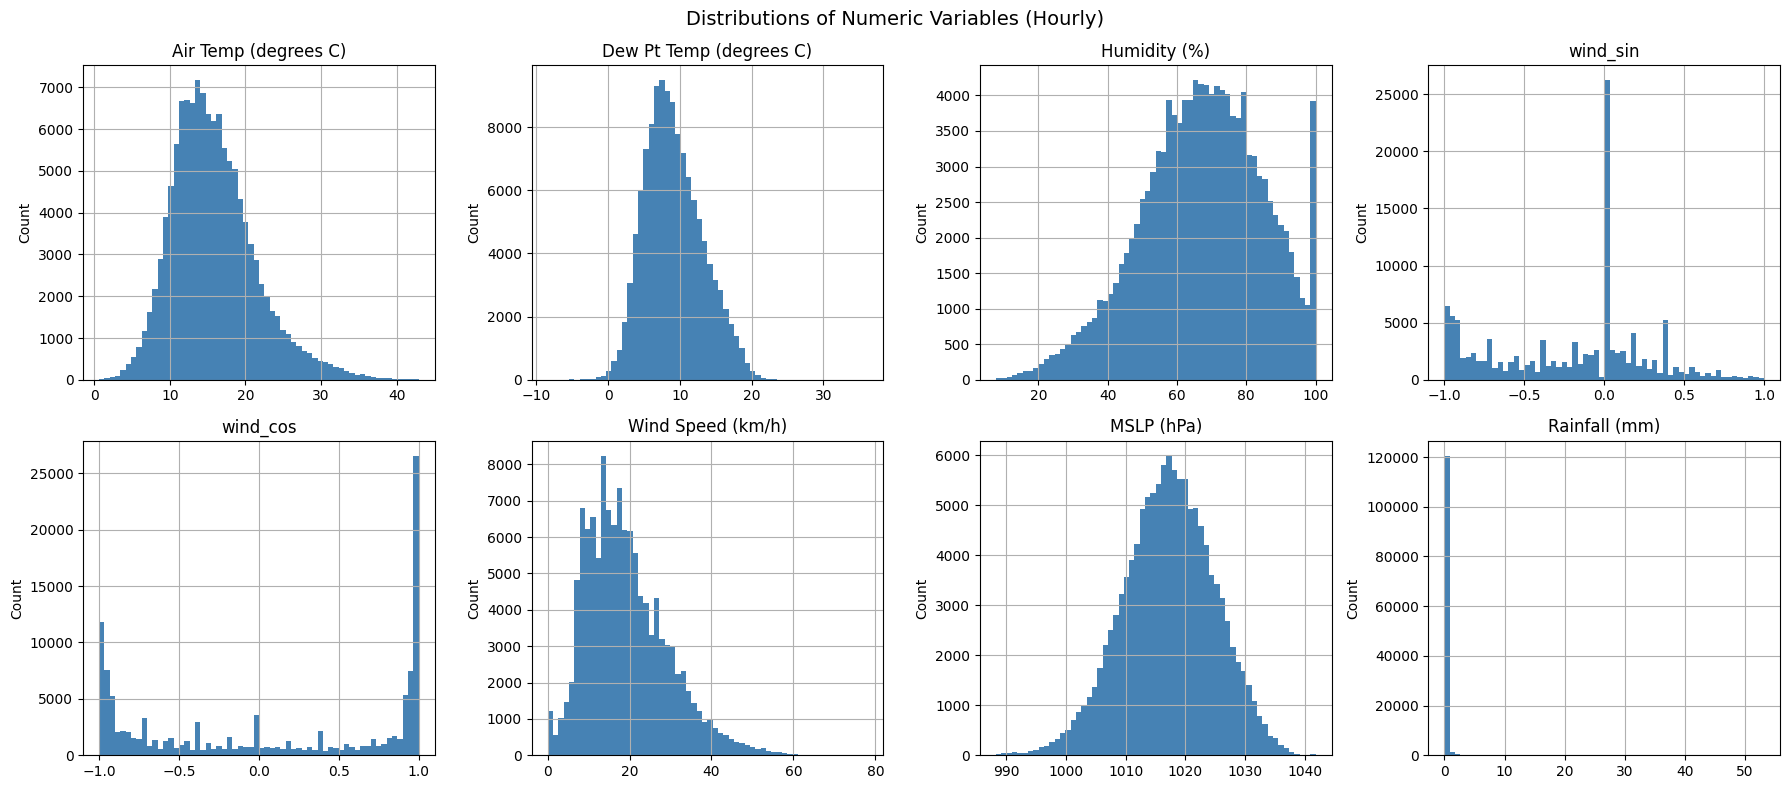

In [241]:
numeric_cols = ['Air Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
                'wind_sin', 'wind_cos', 'Wind Speed (km/h)', 'MSLP (hPa)', 'Rainfall (mm)']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distributions of Numeric Variables (Hourly)', fontsize=14)

for ax, col in zip(axes.flatten(), numeric_cols):
    all_df[col].hist(bins=60, ax=ax, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

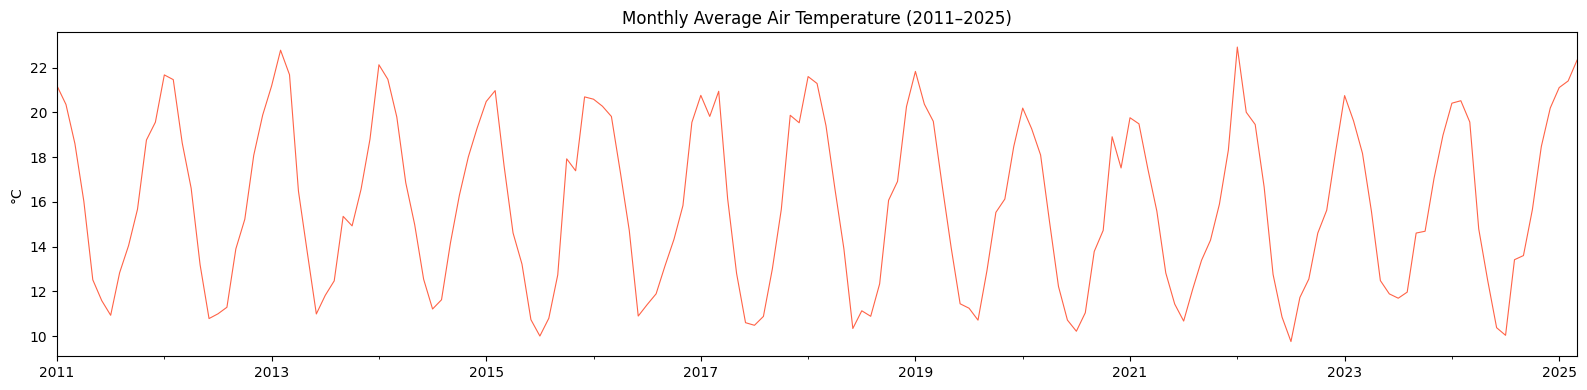

In [242]:
# Monthly average temperature — seasonal pattern
monthly_avg = all_df['Air Temp (degrees C)'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(16, 4))
monthly_avg.plot(ax=ax, color='tomato', linewidth=0.8)
ax.set_title('Monthly Average Air Temperature (2011–2025)')
ax.set_ylabel('°C')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

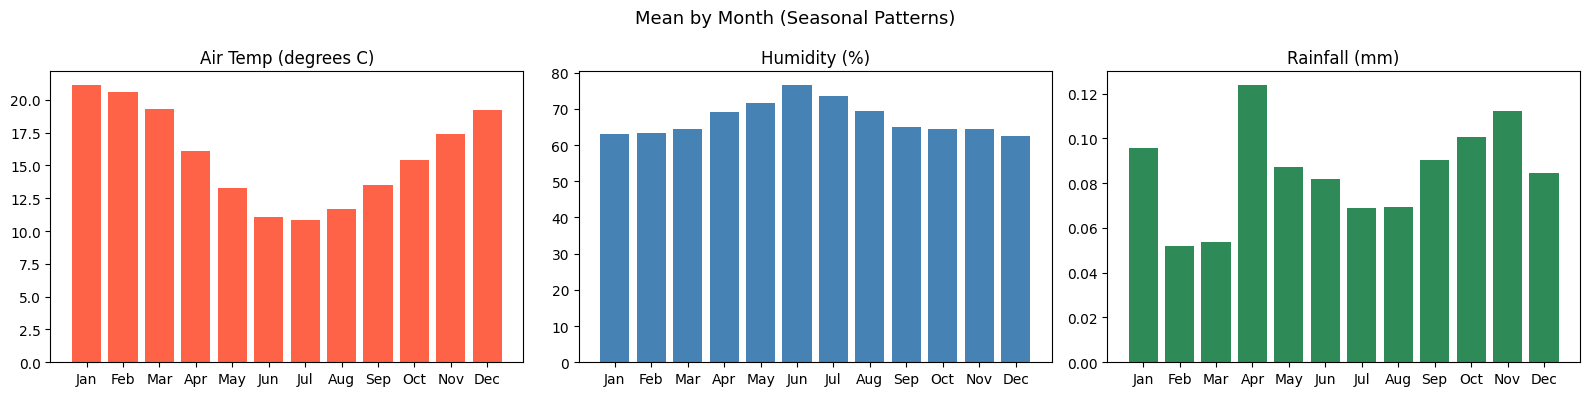

In [243]:
# Average by month-of-year to show seasonality
all_df['month'] = all_df.index.month
seasonal = all_df.groupby('month')[['Air Temp (degrees C)', 'Humidity (%)', 'Rainfall (mm)']].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Mean by Month (Seasonal Patterns)', fontsize=13)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for ax, col, color in zip(axes, seasonal.columns, ['tomato', 'steelblue', 'seagreen']):
    ax.bar(seasonal.index, seasonal[col], color=color)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.set_title(col)

plt.tight_layout()
plt.show()

all_df.drop(columns=['month'], inplace=True)

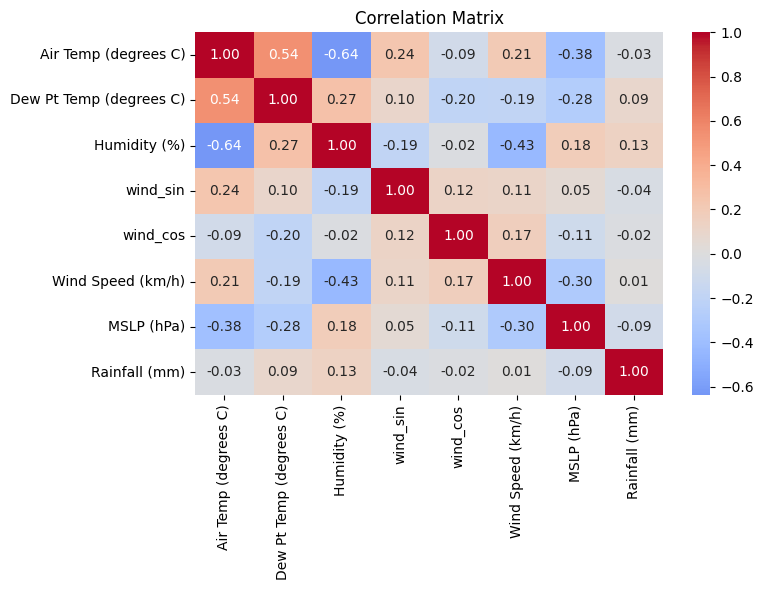

In [244]:
# Correlation heatmap (numeric columns only)
corr = all_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

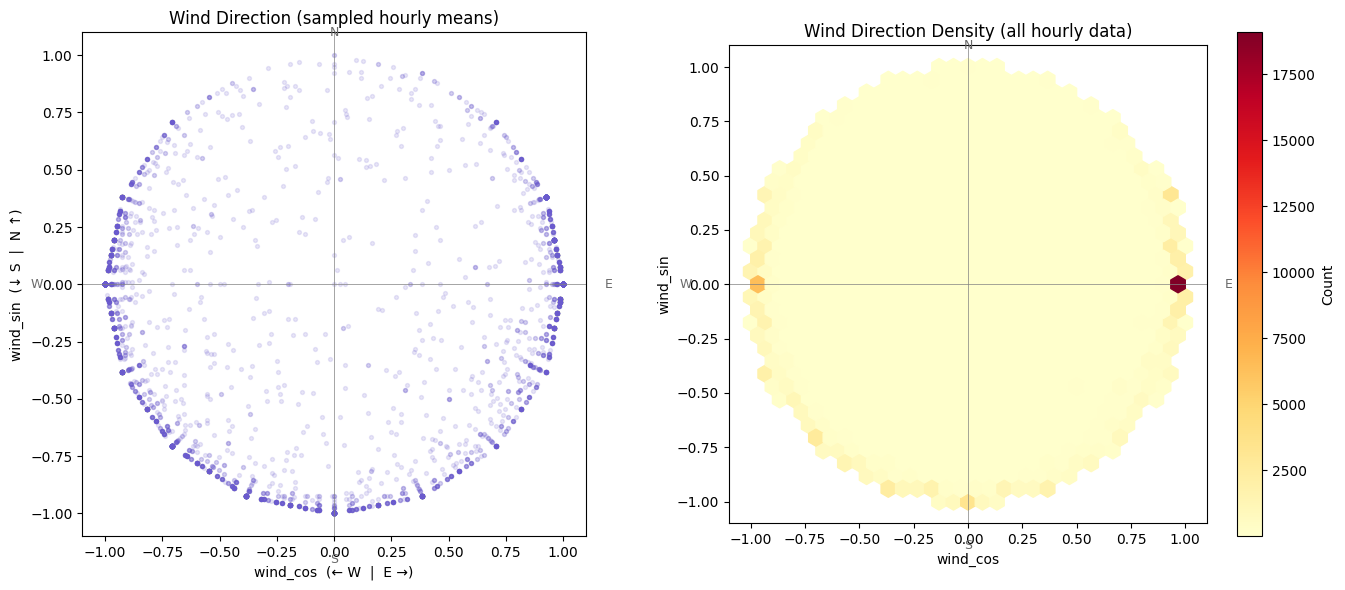

In [245]:
# Wind direction: scatter of hourly-mean sin/cos components on the unit circle
# Dense regions show the prevailing directions over the dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter — sample 5000 points to keep it readable
sample = all_df[['wind_sin', 'wind_cos']].dropna().sample(5000, random_state=42)
axes[0].scatter(sample['wind_cos'], sample['wind_sin'], alpha=0.15, s=8, color='slateblue')
axes[0].set_xlabel('wind_cos  (← W  |  E →)')
axes[0].set_ylabel('wind_sin  (↓ S  |  N ↑)')
axes[0].set_title('Wind Direction (sampled hourly means)')
axes[0].axhline(0, color='grey', linewidth=0.5)
axes[0].axvline(0, color='grey', linewidth=0.5)
axes[0].set_aspect('equal')

# Hexbin density
hb = axes[1].hexbin(all_df['wind_cos'], all_df['wind_sin'],
                    gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('wind_cos')
axes[1].set_ylabel('wind_sin')
axes[1].set_title('Wind Direction Density (all hourly data)')
axes[1].axhline(0, color='grey', linewidth=0.5)
axes[1].axvline(0, color='grey', linewidth=0.5)
axes[1].set_aspect('equal')
fig.colorbar(hb, ax=axes[1], label='Count')

# Compass annotations
for label, (cx, cy) in [('N',(0,1.1)),('S',(0,-1.2)),('E',(1.2,0)),('W',(-1.3,0))]:
    for ax in axes:
        ax.text(cx, cy, label, ha='center', va='center', fontsize=9, color='dimgrey')

plt.tight_layout()
plt.show()

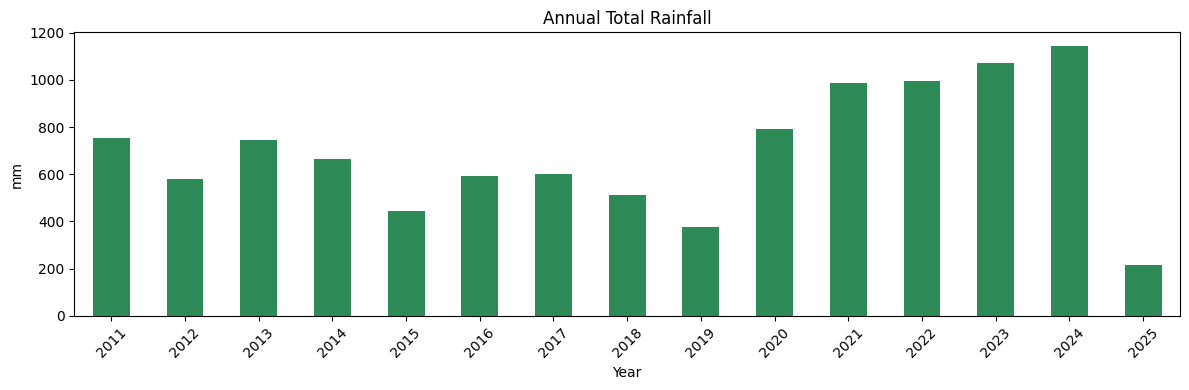

In [246]:
# Rainfall: annual total (summing hourly increments gives true annual rainfall)
all_df['year'] = all_df.index.year
annual_rain = all_df.groupby('year')['Rainfall (mm)'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
annual_rain.plot(kind='bar', ax=ax, color='seagreen')
ax.set_title('Annual Total Rainfall')
ax.set_ylabel('mm')
ax.set_xlabel('Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

all_df.drop(columns=['year'], inplace=True)

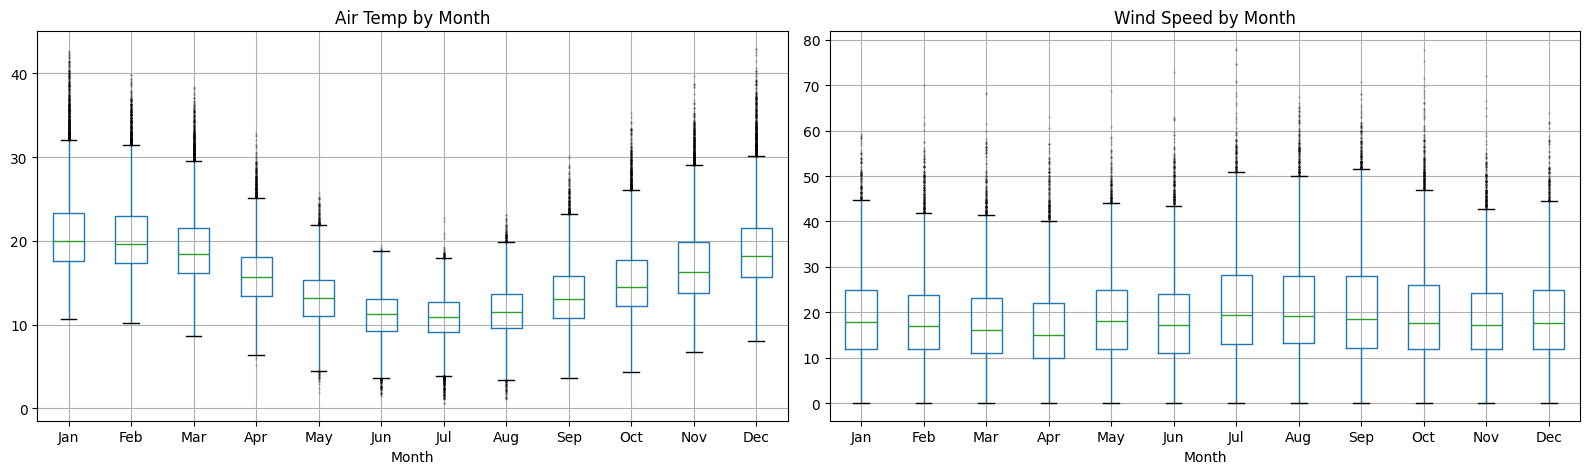

In [247]:
# Boxplots by month to visualise spread and outliers
all_df['month'] = all_df.index.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

all_df.boxplot(column='Air Temp (degrees C)', by='month', ax=axes[0], 
               flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[0].set_title('Air Temp by Month')
axes[0].set_xlabel('Month')
axes[0].set_xticklabels(month_labels)

all_df.boxplot(column='Wind Speed (km/h)', by='month', ax=axes[1],
               flierprops=dict(marker='.', markersize=1, alpha=0.3))
axes[1].set_title('Wind Speed by Month')
axes[1].set_xlabel('Month')
axes[1].set_xticklabels(month_labels)

fig.suptitle('')
plt.tight_layout()
plt.show()

all_df.drop(columns=['month'], inplace=True)

## Feature Engineering

In [248]:
# Aggregate hourly -> daily
daily_df = all_df.resample('D').agg({
    'Air Temp (degrees C)':     ['mean', 'min', 'max'],
    'Dew Pt Temp (degrees C)':  'mean',
    'Humidity (%)':             'mean',
    'wind_sin':                 'mean',
    'wind_cos':                 'mean',
    'Wind Speed (km/h)':        ['mean', 'max'],
    'MSLP (hPa)':               'mean',
    'Rainfall (mm)':            'sum',
})
daily_df.columns = ['_'.join(c).strip() for c in daily_df.columns]
daily_df = daily_df.rename(columns={
    'Air Temp (degrees C)_mean': 'temp_mean',
    'Air Temp (degrees C)_min':  'temp_min',
    'Air Temp (degrees C)_max':  'temp_max',
    'Dew Pt Temp (degrees C)_mean': 'dewpt_mean',
    'Humidity (%)_mean':         'humidity_mean',
    'wind_sin_mean':             'wind_sin',
    'wind_cos_mean':             'wind_cos',
    'Wind Speed (km/h)_mean':    'wind_speed_mean',
    'Wind Speed (km/h)_max':     'wind_speed_max',
    'MSLP (hPa)_mean':          'mslp_mean',
    'Rainfall (mm)_sum':        'rainfall_total',
})
daily_df = daily_df.dropna(subset=['temp_mean'])
print(daily_df.shape)
daily_df.head()

(5182, 11)


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,rainfall_total
Timestamp,,,,,,,,,,,
2011-01-01,19.730208,16.916667,24.600000,12.075764,61.636806,-0.050928,-0.683023,14.066667,26.400000,1011.634514,0.0
2011-01-02,18.020500,15.360000,20.683333,8.278500,53.443333,0.151935,-0.955823,21.477500,31.000000,1016.154583,0.0
2011-01-03,16.548611,14.266667,19.800000,5.492222,48.038889,0.254123,-0.919064,24.220833,30.800000,1016.905972,0.0
2011-01-04,16.827708,13.150000,20.716667,8.932153,60.083333,-0.025413,-0.861826,15.683333,25.333333,1012.337986,0.0
2011-01-05,18.089514,14.700000,21.183333,11.718333,66.663194,-0.327862,-0.665911,19.762500,29.500000,1010.039444,0.0


In [249]:
# Cyclical time features: day-of-year encodes the annual cycle
doy = daily_df.index.day_of_year
daily_df['doy_sin'] = np.sin(2 * np.pi * doy / 365)
daily_df['doy_cos'] = np.cos(2 * np.pi * doy / 365)

# Month as integer (useful for tree models)
daily_df['month'] = daily_df.index.month

daily_df[['doy_sin', 'doy_cos', 'month']].head()

,doy_sin,doy_cos,month
Timestamp,,,
2011-01-01,0.017213,0.999852,1
2011-01-02,0.034422,0.999407,1
2011-01-03,0.051620,0.998667,1
2011-01-04,0.068802,0.997630,1
2011-01-05,0.085965,0.996298,1


In [250]:
# Lag features: weather from 1, 2, 3, and 7 days ago
lag_cols = ['temp_mean', 'temp_max', 'humidity_mean', 'mslp_mean',
            'wind_speed_mean', 'rainfall_total', 'wind_sin', 'wind_cos']

for lag in [1, 2, 3, 7]:
    for col in lag_cols:
        daily_df[f'{col}_lag{lag}'] = daily_df[col].shift(lag)

print(f'Features after lag engineering: {daily_df.shape[1]}')
daily_df.head()

Features after lag engineering: 46


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,...,wind_sin_lag3,wind_cos_lag3,temp_mean_lag7,temp_max_lag7,humidity_mean_lag7,mslp_mean_lag7,wind_speed_mean_lag7,rainfall_total_lag7,wind_sin_lag7,wind_cos_lag7
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-01,19.730208,16.916667,24.600000,12.075764,61.636806,-0.050928,-0.683023,14.066667,26.400000,1011.634514,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-02,18.020500,15.360000,20.683333,8.278500,53.443333,0.151935,-0.955823,21.477500,31.000000,1016.154583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-03,16.548611,14.266667,19.800000,5.492222,48.038889,0.254123,-0.919064,24.220833,30.800000,1016.905972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-04,16.827708,13.150000,20.716667,8.932153,60.083333,-0.025413,-0.861826,15.683333,25.333333,1012.337986,...,-0.050928,-0.683023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-05,18.089514,14.700000,21.183333,11.718333,66.663194,-0.327862,-0.665911,19.762500,29.500000,1010.039444,...,0.151935,-0.955823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [251]:
# Target: did it rain the NEXT day? (total > 0.2mm to exclude trace rain)
RAIN_THRESHOLD = 0.2
daily_df['rain_tomorrow'] = (daily_df['rainfall_total'].shift(-1) > RAIN_THRESHOLD).astype(int)

# Drop last row (no known next-day label) and rows with NaN lags (first 7 days)
daily_df = daily_df.dropna()

print(daily_df['rain_tomorrow'].value_counts())
print(f'Rain days: {daily_df["rain_tomorrow"].mean()*100:.1f}%')
print(f'Total rows: {len(daily_df)}')
daily_df.head()

rain_tomorrow
0    3290
1    1885
Name: count, dtype: int64
Rain days: 36.4%
Total rows: 5175


,temp_mean,temp_min,temp_max,dewpt_mean,humidity_mean,wind_sin,wind_cos,wind_speed_mean,wind_speed_max,mslp_mean,...,wind_cos_lag3,temp_mean_lag7,temp_max_lag7,humidity_mean_lag7,mslp_mean_lag7,wind_speed_mean_lag7,rainfall_total_lag7,wind_sin_lag7,wind_cos_lag7,rain_tomorrow
Timestamp,,,,,,,,,,,,,,,,,,,,,
2011-01-08,26.264889,19.580000,33.150000,14.711111,50.841111,-0.126407,0.433755,29.122222,39.000000,1008.669667,...,-0.665911,19.730208,24.600000,61.636806,1011.634514,14.066667,0.0,-0.050928,-0.683023,0
2011-01-09,20.359028,18.300000,22.183333,15.054444,71.717361,-0.054107,-0.920219,20.413889,26.200000,1017.195417,...,-0.201278,18.020500,20.683333,53.443333,1016.154583,21.477500,0.0,0.151935,-0.955823,1
2011-01-10,21.469861,19.840000,24.560000,18.823542,85.059028,-0.332436,-0.358506,8.390972,12.333333,1013.887014,...,0.986679,16.548611,19.800000,48.038889,1016.905972,24.220833,0.0,0.254123,-0.919064,1
2011-01-11,22.491111,20.816667,25.550000,20.264028,87.625694,0.316587,-0.129764,9.508333,23.800000,1009.369444,...,0.433755,16.827708,20.716667,60.083333,1012.337986,15.683333,0.0,-0.025413,-0.861826,1
2011-01-12,24.061667,21.340000,26.733333,21.028611,83.513889,0.383121,0.490689,18.098611,37.400000,1003.879444,...,-0.920219,18.089514,21.183333,66.663194,1010.039444,19.762500,0.0,-0.327862,-0.665911,1


## PCA

In [252]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Temporal split: last 2 years as test
split_date = '2023-01-01'
train = daily_df[daily_df.index < split_date]
test  = daily_df[daily_df.index >= split_date]

X_train = train.drop(columns=['rain_tomorrow'])
y_train = train['rain_tomorrow']
X_test  = test.drop(columns=['rain_tomorrow'])
y_test  = test['rain_tomorrow']

print(f'Train: {len(X_train)} days  ({X_train.index.min().date()} to {X_train.index.max().date()})')
print(f'Test:  {len(X_test)} days  ({X_test.index.min().date()} to {X_test.index.max().date()})')
print(f'Train rain rate: {y_train.mean()*100:.1f}%  |  Test rain rate: {y_test.mean()*100:.1f}%')

Train: 4373 days  (2011-01-08 to 2022-12-31)
Test:  802 days  (2023-01-01 to 2025-03-12)
Train rain rate: 35.2%  |  Test rain rate: 43.0%


In [253]:
# Scale: fit on train only, apply to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [254]:
# Fit PCA on training set only
pca = PCA()
pca.fit(X_train_scaled)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

# How many components reach 95%?
n_95 = (cumulative < 0.95).sum() + 1
print(f'Components to explain 95% of variance: {n_95} (out of {X_train_scaled.shape[1]})')

Components to explain 95% of variance: 27 (out of 46)


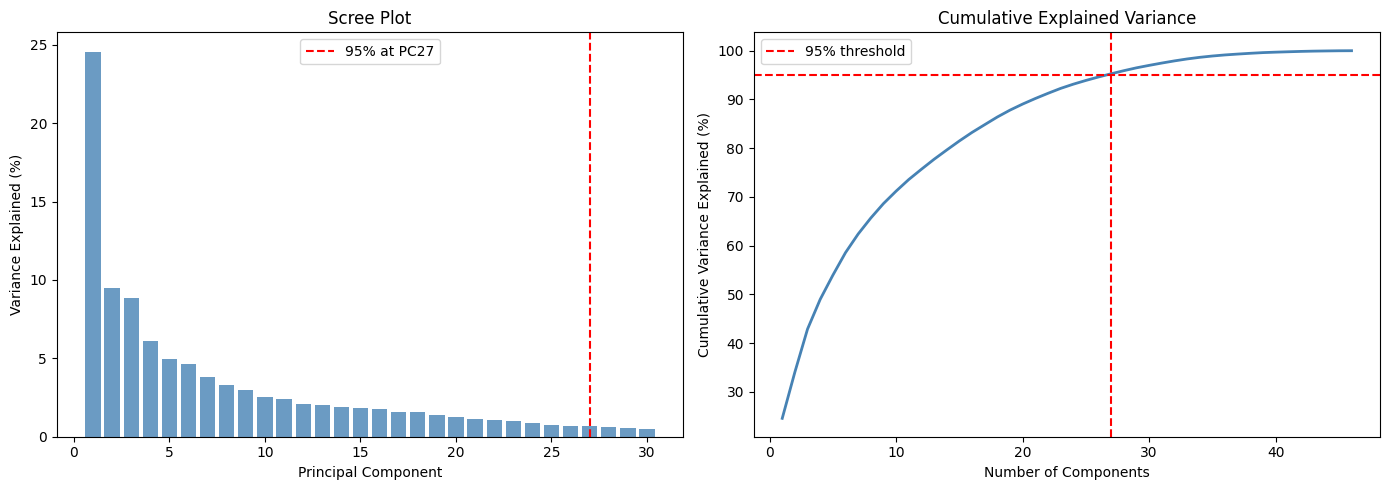

In [255]:
# Scree plot + cumulative explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (first 30 components)
axes[0].bar(range(1, 31), explained[:30] * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')
axes[0].axvline(n_95, color='red', linestyle='--', label=f'95% at PC{n_95}')
axes[0].legend()

# Cumulative variance
axes[1].plot(range(1, len(cumulative) + 1), cumulative * 100, color='steelblue', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_95, color='red', linestyle='--')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()

In [256]:
# Transform train and test to n_95 components
pca_final = PCA(n_components=n_95)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

print(f'X_train_pca shape: {X_train_pca.shape}')
print(f'X_test_pca shape:  {X_test_pca.shape}')

X_train_pca shape: (4373, 27)
X_test_pca shape:  (802, 27)


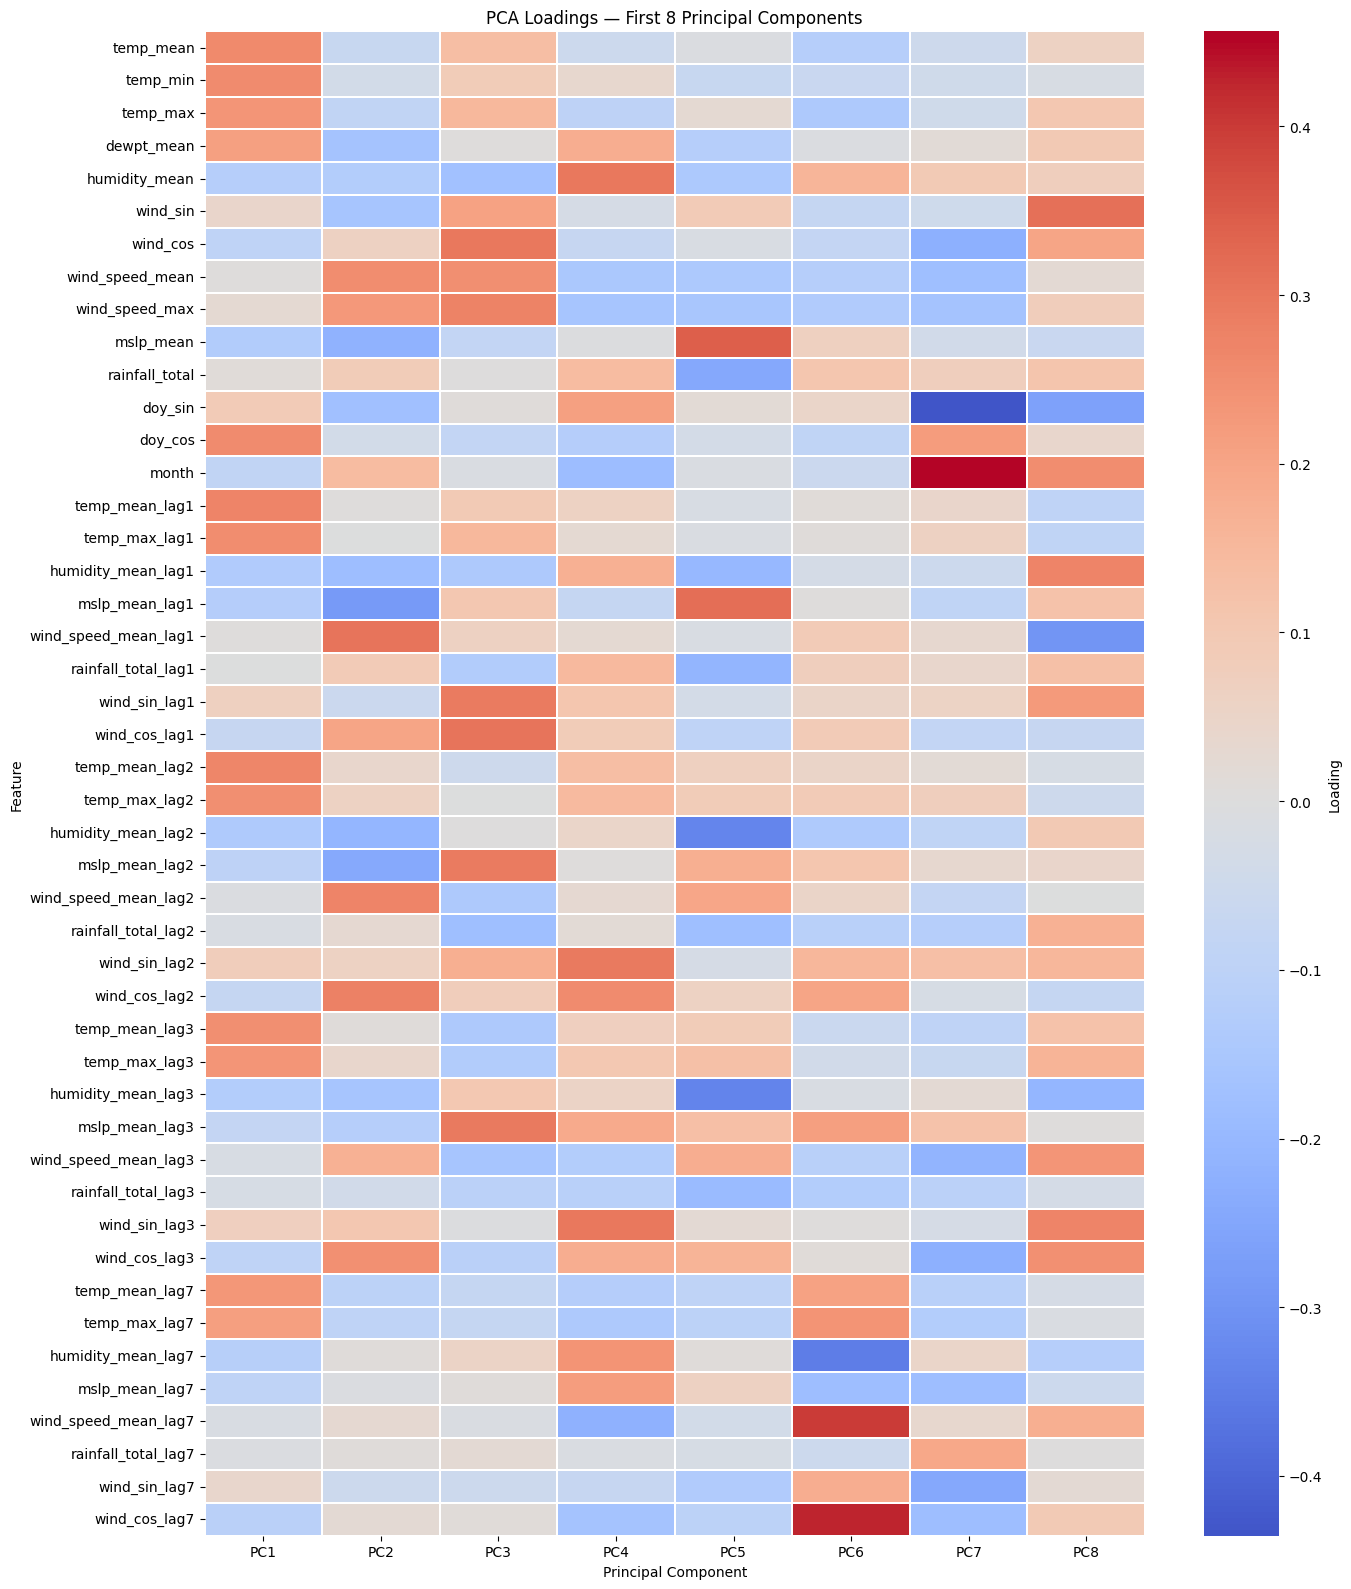

In [257]:
# Loadings heatmap: which original features drive each of the first 8 PCs
import seaborn as sns

n_show = 8
loadings = pd.DataFrame(
    pca_final.components_[:n_show].T,
    index=X_train.columns,
    columns=[f'PC{i+1}' for i in range(n_show)]
)

fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(loadings, cmap='coolwarm', center=0, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Loading'})
ax.set_title('PCA Loadings — First 8 Principal Components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## Logistic Regression

In [258]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Train on PCA-transformed data
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pca, y_train)

y_pred  = lr.predict(X_test_pca)
y_proba = lr.predict_proba(X_test_pca)[:, 1]

print("Classification Report")
print("=" * 45)
print(classification_report(y_test, y_pred, target_names=['No Rain', 'Rain']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

Classification Report
              precision    recall  f1-score   support

     No Rain       0.70      0.91      0.79       457
        Rain       0.80      0.48      0.60       345

    accuracy                           0.72       802
   macro avg       0.75      0.69      0.69       802
weighted avg       0.74      0.72      0.71       802

ROC-AUC: 0.7945


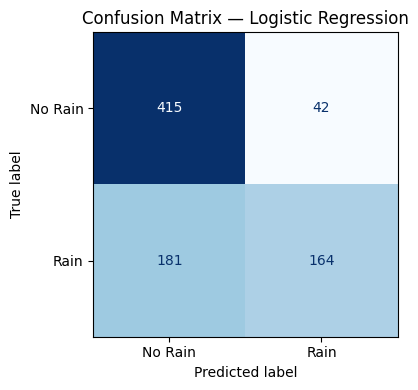

In [259]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['No Rain', 'Rain']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()